# 01r `|+>` quench benchmark — finite 3×3 lattice, 5 backends

Companion to `run_quench_benchmark.ipynb` (the `1r` benchmark), for the **three-level `01r`**
system (`|0>`, `|1>`, `|r>`). Every site starts in `|+> = (|0>+|1>)/√2`. The pulse drives
**only the |1>–|r> transition** (`Omega_hf = 0`, so the **0–1 Rabi is closed** and `|0>` is a
spectator) while sweeping the Rydberg detuning `Delta_R` across resonance — i.e. a Rydberg
**phase gate**: the `|1>` branch of each qubit picks up an accumulated phase (single-site +
blockade-induced many-body), so the final state is

$$\;\;|\psi\rangle \;\approx\; \frac{1}{\sqrt{2^N}}\sum_{s\in\{0,1\}^N} e^{i\varphi(s)}\,|s\rangle\,.$$

**What we plot**
- **Per-site `√P₀₁`** (amplitude that returned to the qubit subspace, `√(1-⟨n_r⟩)`) as 2D
  color maps — for the four **finite** backends `exact`, `mps` (TeNPy), `peps` (YASTN), `gputn`.
- **Per-string accumulated phase `φ(s)`** over all `2⁹ = 512` computational strings — from the
  **exact** state vector (the only backend exposing full amplitudes).
- **`pepskit`** is an *infinite/bulk* iPEPS (basis-state init only) → shown in a **separate
  bulk panel** from `|1>`, as a thermodynamic-limit reference, not part of the finite `|+>` run.

`01r` has local dim 3, so the Hilbert space is `3⁹ ≈ 19.7k` — exact and gputn-statevector are
both feasible at 3×3 (4×4 would be `3¹⁶ = 43M`).

In [ ]:
# Pin BLAS/OpenMP to 1 thread BEFORE importing numpy/scipy/tenpy.
# Small TN tensors (DMRG/TDVP/PEPS) => multi-threaded BLAS oversubscribes
# cores and runs 10-40x SLOWER on a loaded box. This cell must stay first
# and run before any import: the libraries read these variables only once,
# at import time.
import os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ.setdefault(_v, "1")
print("BLAS/OpenMP threads pinned to", os.environ.get("OMP_NUM_THREADS"))

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt

import ryd_gate as rg
from ryd_gate import InteractionSpec
from ryd_gate.lattice import Register
from ryd_gate.protocols.digital_analog import DigitalAnalogProtocol

# --- geometry / level structure ---
Lx, Ly = 3, 3
N = Lx * Ly
a_um = 6.8                         # lattice spacing, um
C6 = 2 * np.pi * 874e9             # rad/s * um^6 (Rb 70S typical)

# --- pulse: same shape as run_quench_benchmark but on the |1>-|r> transition.
#     Smooth flat-top Omega_R + cosine round-trip Delta_R (-amp -> +amp -> -amp), so the |1>
#     branch is driven across resonance and back, *returning* population to the qubit subspace
#     with an accumulated phase. Omega_hf = 0 -> the 0-1 Rabi is closed and |0> is a spectator.
Omega_R = 2 * np.pi * 3.8e6        # |1>-|r> Rabi (plateau), rad/s
delta_amp = 2 * np.pi * 8.0e6      # Rydberg detuning amplitude (round trip -amp..+amp..-amp)
t_sweep = 1.5e-6                   # total quench time, s
ramp_frac = 0.15                   # smootherstep edge width of the Omega_R flat-top

def _smootherstep(u):
    u = np.clip(u, 0.0, 1.0)
    return 10 * u**3 - 15 * u**4 + 6 * u**5

def omega_R_at(s):                 # s = t / t_sweep in [0, 1]
    if s < ramp_frac:
        return Omega_R * _smootherstep(s / ramp_frac)
    if s > 1.0 - ramp_frac:
        return Omega_R * _smootherstep((1.0 - s) / ramp_frac)
    return Omega_R

def delta_R_at(s):
    return -delta_amp * np.cos(2.0 * np.pi * s)   # -amp at s=0, +amp at s=0.5, -amp at s=1

n_seg = 80
segments = [
    Segment(duration=t_sweep / n_seg,
            omega_R=omega_R_at((k + 0.5) / n_seg),
            delta_R=delta_R_at((k + 0.5) / n_seg))
    for k in range(n_seg)
]
protocol = segments_protocol(segments)   # Omega_hf defaults to 0 -> 0-1 Rabi closed

geom = Register.rectangle(Lx, Ly, spacing_um=a_um)
system = rg.RydbergSystem.from_lattice(
    geom, "01r",
    interaction=InteractionSpec(C6=C6, mode="nn"),   # nearest-neighbour blockade
    protocol=protocol,
)
t_eval = np.linspace(0.0, t_sweep, 7)
dt_tn = 0.4 / Omega_R              # TN Trotter step (coarse for tractable runtime; 0.2 for production)
V_nn = C6 / a_um**6
tn_results = {}                    # filled by run_tn() below; defined here so §2 plots are robust
print(f"3x3 01r: dim = 3^9 = {3**9};  t_gate = {t_sweep*1e6:.3f} us;  "
      f"n_steps ~ {int(np.ceil(t_sweep/dt_tn))};  V_nn/Omega_R = {V_nn/Omega_R:.2f}")

3x3 01r: dim = 3^9 = 19683;  t_gate = 1.500 us;  n_steps ~ 90;  V_nn/Omega_R = 2.33


In [ ]:
# Local compatibility shim: the kernel DigitalAnalogProtocol is now function-
# based (omega_R_fn(t), ...). These notebooks keep their piecewise-constant
# Segment schedules and lower them to step functions here. Note the backend
# integrates on n_steps uniform slices, so segment edges should be resolved
# by a generous n_steps (the notebooks already scale it with len(segments)).
from dataclasses import dataclass

import numpy as np


@dataclass
class Segment:
    duration: float
    omega_R: "float | np.ndarray" = 0.0
    omega_hf: "float | np.ndarray" = 0.0
    delta_R: "float | np.ndarray" = 0.0
    delta_hf: "float | np.ndarray" = 0.0


def segments_protocol(segments, n_steps=200):
    """Build the function-based DigitalAnalogProtocol from constant segments."""
    segments = list(segments)
    edges = np.cumsum([0.0] + [float(seg.duration) for seg in segments])

    def step_fn(name):
        values = [getattr(seg, name) for seg in segments]

        def fn(t):
            j = int(np.clip(np.searchsorted(edges, t, side="right") - 1, 0, len(values) - 1))
            return values[j]

        return fn

    protocol = DigitalAnalogProtocol(
        t_gate=float(edges[-1]),
        omega_R_fn=step_fn("omega_R"),
        omega_hf_fn=step_fn("omega_hf"),
        delta_R_fn=step_fn("delta_R"),
        delta_hf_fn=step_fn("delta_hf"),
        n_steps=n_steps,
    )
    protocol.segments = segments  # keep the schedule inspectable for plotting
    return protocol


## 1. Exact baseline (full state vector)

`backend="exact"` keeps the dense state vector at each `t_eval`, so it gives both the per-site
occupations (for `√P₀₁`) and the full per-string amplitudes/phases used in §4.

In [2]:
_t0 = time.perf_counter()
res_exact = rg.simulate(system, [], "plus", backend="exact", t_eval=t_eval)
exact_elapsed = time.perf_counter() - _t0

d = system.basis.local_dim   # 3, levels ("0","1","r")

def per_site_occ(psi, level):
    return np.array([system.expectation(f"n_{level}_{i}", psi) for i in range(N)])

# sqrt(P_01) per site = sqrt(<n_0> + <n_1>) = sqrt(1 - <n_r>); shape (T, N) in 2D site order.
exact_nr = np.array([per_site_occ(psi, "r") for psi in res_exact.states])
exact_sqrtP01 = np.sqrt(np.clip(1.0 - exact_nr, 0.0, 1.0))
exact_nmean_r = exact_nr.mean(axis=1)

print(f"exact elapsed: {exact_elapsed:.2f} s")
print("t(us)   <n_r>   <n_0>   <n_1>")
for psi, t in zip(res_exact.states, res_exact.times):
    print(f"{t*1e6:6.3f}  {per_site_occ(psi,'r').mean():.4f}  "
          f"{per_site_occ(psi,'0').mean():.4f}  {per_site_occ(psi,'1').mean():.4f}")

exact elapsed: 4.64 s
t(us)   <n_r>   <n_0>   <n_1>
 0.000  0.0000  0.5000  0.5000
 0.248  0.0531  0.5000  0.4469
 0.503  0.2951  0.5000  0.2049
 0.750  0.3346  0.5000  0.1654
 0.998  0.2877  0.5000  0.2123
 1.253  0.0590  0.5000  0.4410
 1.500  0.0150  0.5000  0.4850


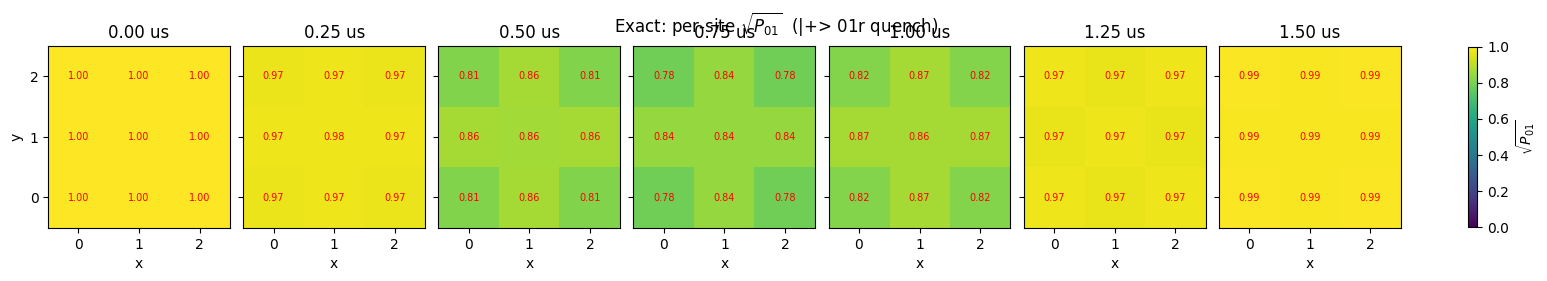

In [3]:
def plot_2d_maps(sqrtP01, times, title):
    # 3x3 per-site color map of sqrt(P_01) at each t_eval (run_quench_benchmark style).
    T = len(times)
    fig, axes = plt.subplots(1, T, figsize=(2.2 * T, 2.5), constrained_layout=True)
    axes = np.atleast_1d(axes)
    im = None
    for ax, t, row in zip(axes, times, sqrtP01):
        grid = np.asarray(row).reshape(Lx, Ly)
        im = ax.imshow(grid.T, origin="lower", vmin=0.0, vmax=1.0, cmap="viridis")
        ax.set_title(f"{t*1e6:.2f} us")
        ax.set_xticks(range(Lx)); ax.set_yticks(range(Ly))
        ax.set_xlabel("x")
        ax.set_ylabel("y") if ax is axes[0] else ax.set_yticklabels([])
        for ix in range(Lx):
            for iy in range(Ly):
                ax.text(ix, iy, f"{grid[ix,iy]:.2f}", ha="center", va="center", color="red", fontsize=7)
    fig.colorbar(im, ax=axes, shrink=0.82, label=r"$\sqrt{P_{01}}$")
    fig.suptitle(title, y=1.05)
    plt.show()

plot_2d_maps(exact_sqrtP01, res_exact.times, r"Exact: per-site $\sqrt{P_{01}}$  (|+> 01r quench)")

## 2. Tensor-network backends (finite): `mps`, `peps`, `gputn`

Same `|+>` quench, same `system`. Each returns per-site `n_0/n_1/n_r` observables, from which we
form the `√P₀₁` 2D map and compare the mean `⟨n_r⟩(t)` against the exact reference.

`gputn` is forced to its exact `statevector` kernel (the `"auto"` cuTensorNet path can hang on
small lattices); `peps` runs on CPU (set `use_cuda=True, yastn_backend="torch"` for GPU).

/home/chance/Ryd-gate-modeling/.venv/lib/python3.12/site-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width)


mps    elapsed:    21.1 s   max|Δ⟨n_r⟩| vs exact = 6.641e-03


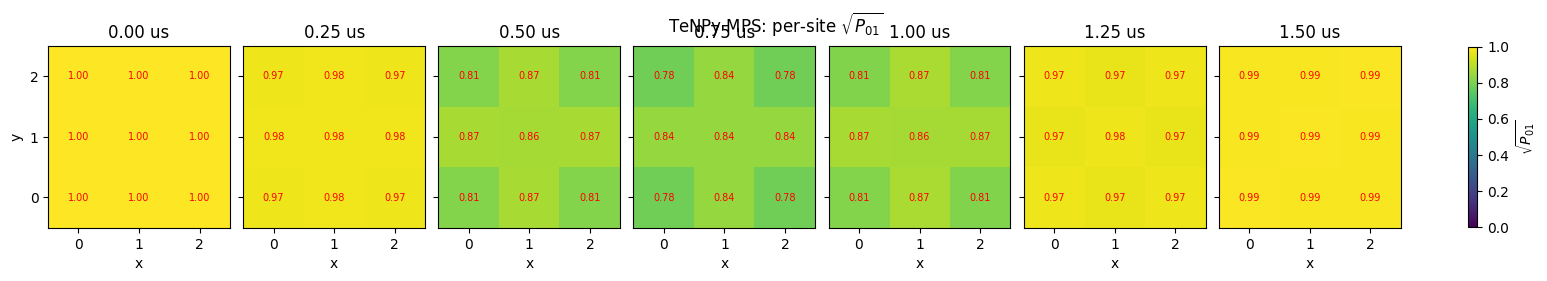

In [4]:
def run_tn(backend, opts):
    _t0 = time.perf_counter()
    res = rg.simulate(
        system, [], "plus", backend=backend, t_eval=t_eval,
        observables=["n_0", "n_1", "n_r"], backend_options=opts,
    )
    elapsed = time.perf_counter() - _t0
    nr = np.asarray(res.metadata["obs"]["n_r"])          # (T, N), 2D site order
    sqrtP01 = np.sqrt(np.clip(1.0 - nr, 0.0, 1.0))
    diff = float(np.max(np.abs(nr.mean(axis=1) - exact_nmean_r)))
    tn_results[backend] = dict(res=res, sqrtP01=sqrtP01, nr_mean=nr.mean(axis=1), elapsed=elapsed, diff=diff)
    print(f"{backend:6s} elapsed: {elapsed:7.1f} s   max|Δ⟨n_r⟩| vs exact = {diff:.3e}")
    return tn_results[backend]

mps = run_tn("mps", {"chi_max": 16, "dt": dt_tn, "svd_min": 1e-10})
plot_2d_maps(mps["sqrtP01"], np.asarray(tn_results["mps"]["res"].times),
             r"TeNPy MPS: per-site $\sqrt{P_{01}}$")

gputn  elapsed:     1.0 s   max|Δ⟨n_r⟩| vs exact = 6.932e-03


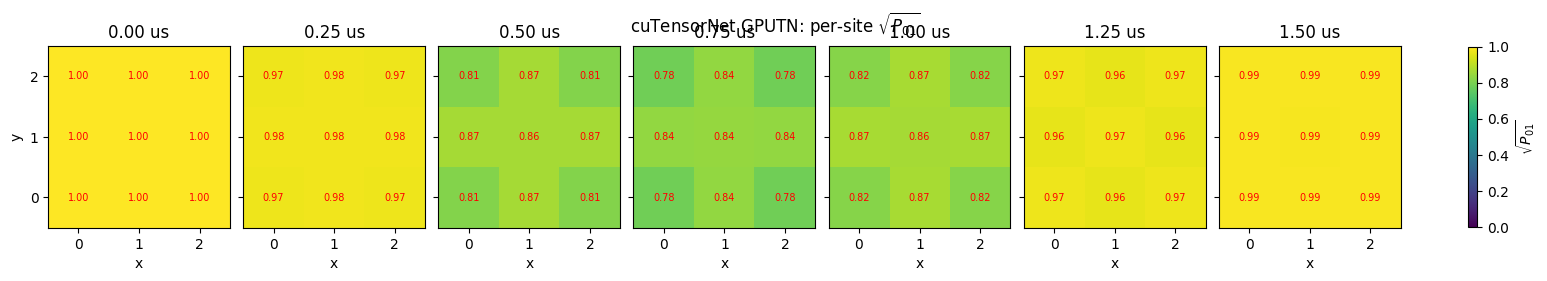

In [5]:
gputn = run_tn("gputn", {"chi_max": 32, "dt": dt_tn, "svd_min": 1e-10,
                          "require_gpu": True, "kernel": "statevector"})
plot_2d_maps(gputn["sqrtP01"], np.asarray(tn_results["gputn"]["res"].times),
             r"cuTensorNet GPUTN: per-site $\sqrt{P_{01}}$")

peps   elapsed:    27.2 s   max|Δ⟨n_r⟩| vs exact = 2.638e-02


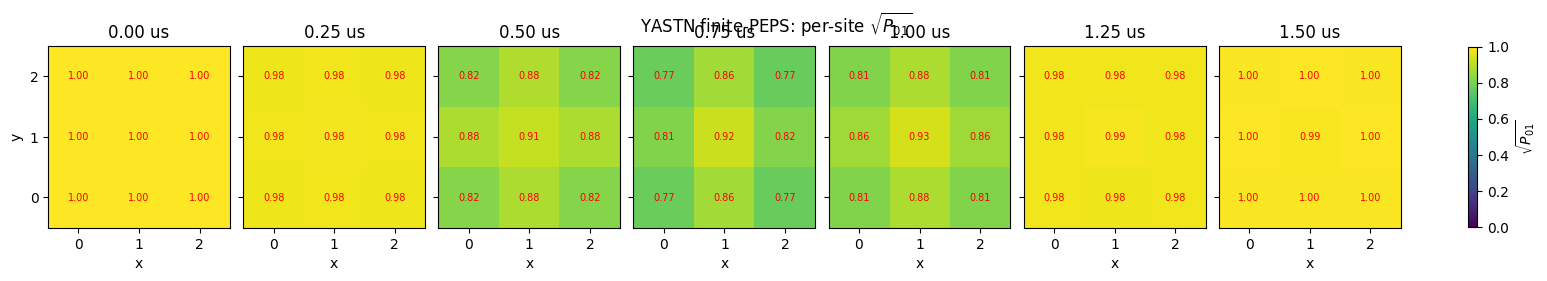

In [6]:
peps = run_tn("peps", {"chi_max": 4, "dt": dt_tn, "svd_min": 1e-8,
                        "measurement_environment": "bp", "update_environment": "ntu",
                        "max_iter": 8, "use_cuda": False})
plot_2d_maps(peps["sqrtP01"], np.asarray(tn_results["peps"]["res"].times),
             r"YASTN finite-PEPS: per-site $\sqrt{P_{01}}$")

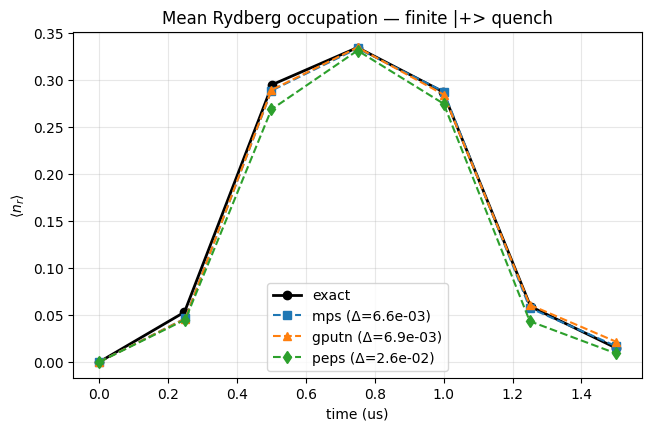

In [7]:
# Agreement check: mean <n_r>(t) across all finite backends (exact = reference).
fig, ax = plt.subplots(figsize=(6.4, 4.2), constrained_layout=True)
ax.plot(res_exact.times * 1e6, exact_nmean_r, "k-o", lw=2, label="exact")
for backend, mk in [("mps", "s--"), ("gputn", "^--"), ("peps", "d--")]:
    if backend in tn_results:
        r = tn_results[backend]
        ax.plot(np.asarray(r["res"].times) * 1e6, r["nr_mean"], mk, label=f"{backend} (Δ={r['diff']:.1e})")
ax.set_xlabel("time (us)"); ax.set_ylabel(r"$\langle n_r \rangle$")
ax.set_title("Mean Rydberg occupation — finite |+> quench"); ax.legend(); ax.grid(alpha=0.3)
plt.show()

## 3. Per-string accumulated phase `φ(s)` (exact, golden)

Project the exact final state onto the qubit subspace `{0,1}⁹` (512 strings). For each string
`s`, `A_s = ⟨s|ψ⟩`; we reference the phase to the all-spectator string `|0…0⟩` (which is frozen,
since `|0>` is decoupled), giving `φ(s) = arg(A_s · conj(A_{0…0}))`. The phase organises by
**Hamming weight** `w` (number of active `|1>` sites): `w=1` reveals the single-qubit phase, and
`w≥2` reveals the blockade-induced pair/many-body phase.

In [8]:
# Map each {0,1}^N string -> its index in the 3^N exact basis (level_index 0/1; idx = sum b_i 3^(N-1-i)).
weights3 = np.array([d ** (N - 1 - i) for i in range(N)], dtype=np.int64)
string_idx = np.zeros(2 ** N, dtype=np.int64)
bits_table = np.zeros((2 ** N, N), dtype=np.int8)
for s in range(2 ** N):
    bits = [(s >> (N - 1 - i)) & 1 for i in range(N)]    # site i (2D order) -> bit
    bits_table[s] = bits
    string_idx[s] = int(np.dot(bits, weights3))

def string_phase_prob(psi):
    amps = np.asarray(psi)[string_idx]
    ref = amps[0]                                         # |0...0>
    phi = np.angle(amps * np.conj(ref))
    return phi, np.abs(amps) ** 2

phi, prob = string_phase_prob(res_exact.states[-1])
weight = bits_table.sum(axis=1)
P_subspace = prob.sum()
print(f"qubit-subspace probability at t_gate = {P_subspace:.4f}  "
      f"(leakage to |r> = {1 - P_subspace:.4f})")
print(f"single-site phase  <φ(w=1)> = {phi[weight==1].mean():+.4f} rad  "
      f"(spread {phi[weight==1].std():.1e})")
# NN vs non-NN pair extra phase (φ_pair - 2*φ_single):
nn = {(min(int(i), int(j)), max(int(i), int(j))) for i, j, _v in system.meta('interaction_pairs', ())}
single = phi[weight == 1].mean()
w2 = np.where(weight == 2)[0]
pair_extra_nn, pair_extra_far = [], []
for s in w2:
    i, j = np.where(bits_table[s] == 1)[0]
    extra = phi[s] - 2 * single
    (pair_extra_nn if (int(i), int(j)) in nn else pair_extra_far).append(extra)
print(f"pair extra phase  NN: {np.mean(pair_extra_nn):+.4f} rad   "
      f"non-NN: {np.mean(pair_extra_far):+.4f} rad")

qubit-subspace probability at t_gate = 0.8699  (leakage to |r> = 0.1301)
single-site phase  <φ(w=1)> = -0.7349 rad  (spread 0.0e+00)
pair extra phase  NN: -1.6565 rad   non-NN: -0.0000 rad


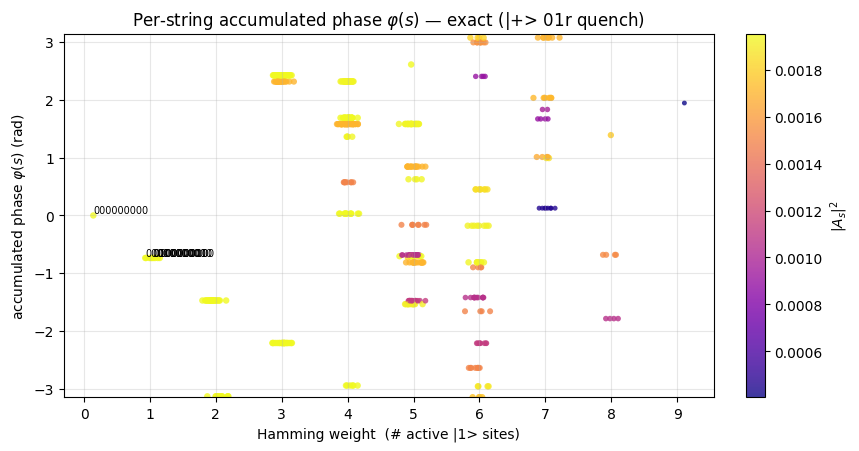

Representative low-weight strings (site order = row-major 3x3):
  string       w   φ(rad)     |A|^2
  000000000   0   -0.0000  0.0020
  000000001   1   -0.7349  0.0020
  000000010   1   -0.7349  0.0020
  000000100   1   -0.7349  0.0020
  000001000   1   -0.7349  0.0020
  000010000   1   -0.7349  0.0020
  000100000   1   -0.7349  0.0020
  001000000   1   -0.7349  0.0020
  010000000   1   -0.7349  0.0020
  100000000   1   -0.7349  0.0020


In [9]:
# Scatter: phase vs Hamming weight, marker size/colour ~ |A_s|^2; dominant strings labelled.
rng = np.random.RandomState(0)
jitter = 0.08 * rng.randn(2 ** N)
fig, ax = plt.subplots(figsize=(8.5, 4.4), constrained_layout=True)
sc = ax.scatter(weight + jitter, phi, c=prob, s=10 + 6000 * prob, cmap="plasma", alpha=0.8, edgecolors="none")
ax.set_xlabel("Hamming weight  (# active |1> sites)")
ax.set_ylabel(r"accumulated phase $\varphi(s)$ (rad)")
ax.set_title(r"Per-string accumulated phase $\varphi(s)$ — exact (|+> 01r quench)")
ax.set_xticks(range(N + 1)); ax.grid(alpha=0.3)
ax.set_ylim(-np.pi, np.pi)
fig.colorbar(sc, ax=ax, label=r"$|A_s|^2$")
for s in np.argsort(prob)[::-1][:6]:                     # label the dominant strings
    ax.annotate("".join(map(str, bits_table[s])), (weight[s] + jitter[s], phi[s]),
                fontsize=7, ha="left", va="bottom")
plt.show()

print("Representative low-weight strings (site order = row-major 3x3):")
print("  string       w   φ(rad)     |A|^2")
for s in list(np.where(weight == 0)[0]) + list(np.where(weight == 1)[0]):
    print(f"  {''.join(map(str, bits_table[s]))}  {weight[s]:2d}  {phi[s]:+8.4f}  {prob[s]:.4f}")

## 4. `pepskit` iPEPS — bulk (thermodynamic-limit) reference

`pepskit` is an **infinite** iPEPS with a translation-invariant 2×2 unit cell and basis-state
initialisation, so it cannot represent the finite `|+>` state or per-string phases. Shown here
as a separate **bulk** panel: the same pulse from `|1>`, reporting bulk occupations. Needs Julia
+ PEPSKit.jl (first call pays the cold-start JIT); guarded so the notebook still completes if the
Julia kernel is unavailable.

pepskit bulk elapsed: 106.7 s


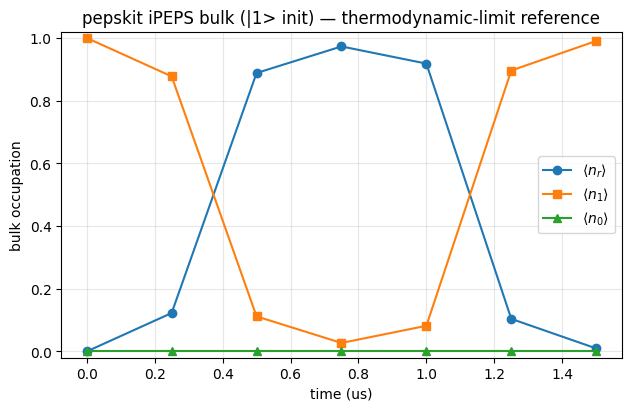

In [10]:
# Bulk iPEPS uses a 2x2 unit cell; build a matching 2x2 01r system with the same pulse.
bulk_system = rg.RydbergSystem.from_lattice(
    Register.rectangle(2, 2, spacing_um=a_um), "01r",
    interaction=InteractionSpec(C6=C6, mode="nn"), protocol=protocol,
)
try:
    _t0 = time.perf_counter()
    res_bulk = rg.simulate(
        bulk_system, [], "all_1", backend="pepskit", t_eval=t_eval,
        observables=["n_r", "n_1", "n_0"],
        backend_options={"unit_cell": "uniform", "bond_dim": 3, "env_dim": 16, "dt": dt_tn, "timeout": 1800},
    )
    print(f"pepskit bulk elapsed: {time.perf_counter() - _t0:.1f} s")
    bt = np.asarray(res_bulk.times) * 1e6
    fig, ax = plt.subplots(figsize=(6.2, 4.0), constrained_layout=True)
    for key, mk in [("n_r", "o-"), ("n_1", "s-"), ("n_0", "^-")]:
        ax.plot(bt, np.asarray(res_bulk.metadata["obs"][key]), mk, label=fr"$\langle n_{{{key[-1]}}} \rangle$")
    ax.set_xlabel("time (us)"); ax.set_ylabel("bulk occupation")
    ax.set_title("pepskit iPEPS bulk (|1> init) — thermodynamic-limit reference")
    ax.set_ylim(-0.02, 1.02); ax.legend(); ax.grid(alpha=0.3)
    plt.show()
except Exception as exc:
    print("pepskit bulk panel skipped:", repr(exc)[:300])